## importing some important things

In [8]:
from tqdm.auto import tqdm
import gc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from langchain_ollama import ChatOllama
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

## model definition

In [9]:
# 'qwen2.5:7b','qwen3:1.7b','qwen3.5:0.8b','qwen3.5:4b'
all_models = ['gemma4:e2b','gemma4:e4b']

MODEL_NAME="LiquidAI/lfm2.5-350m"
BASE_URL = "http://localhost:11434"

llm_test = ChatOllama(model=MODEL_NAME,
                 base_url=BASE_URL
                 )
response_test = llm_test.invoke("1+1=?")
response_test.content

'1+1=2'

In [10]:
def read_data(file_path):
    with open(file_path) as f:
        rows = f.read().splitlines()
    return rows[0], rows[1]

## definition llm expreriment

In [11]:
def run_experiments(llm, n_back, system_prompt, letters, founds):
    experiment_result = []

    letter_history = []

    messages = [SystemMessage(content=system_prompt)]

    for letter in letters:
        current_input = f"Input: {letter}"
        letter_history.append(letter)
        messages.append(HumanMessage(content=current_input))
        response = llm.invoke(messages)
        model_answer = response.content.strip().upper()
        messages.append(AIMessage(content=model_answer))

        idx = len(letter_history) - 1
        if idx < n_back:
            correct_answer = "-"
        else:
            correct_answer = "MATCH" if letter_history[idx] == letter_history[idx-n_back] else "NO"

        experiment_result.append({
            "item": letter,
            "model_answer": model_answer,
            "correct_answer": correct_answer,
            "found": founds[idx]
        })

        #print(f"Item: {letter:5} | Model: {model_answer:5} | Correct: {correct_answer:5}| Founds: {founds[idx]:5}")

    return experiment_result

## run experiment


In [12]:
def run_experiments_for_n(llm,n_val,system_prompt,file_count=50):
    all_results = []
    files = ["letters/"+str(n_val)+"back/"+str(i)+".txt"  for i in range(file_count)]

    for file in tqdm(files, desc=f"Processing {n_val}-back files"):
        #print("Running experiments for file {}".format(file))
        letters , founds = read_data(file)
        experiment_result = run_experiments(llm,n_val,system_prompt,letters,founds)
        all_results.extend(experiment_result)
    return all_results

In [13]:
def summarize_results(results):
    total = len(results)

    tn = sum(1 for r in results
        if r["model_answer"] != "MATCH" and r["correct_answer"] != "MATCH")

    tp = sum(1 for r in results
             if r["model_answer"] == "MATCH" and r["correct_answer"] == "MATCH")

    fp = sum(1 for r in results
             if r["model_answer"] == "MATCH" and r["correct_answer"] != "MATCH")

    fn = sum(1 for r in results
             if r["model_answer"] != "MATCH" and r["correct_answer"] == "MATCH")

    accuracy = (tp+tn) / (tp+tn+fp+fn)
    precision = 0 if (tp + fp) == 0 else tp / (tp + fp)
    recall = 0 if (tp + fn) == 0 else tp / (tp + fn)

    return {
        "total": total,
        "correct": tp+tn,
        "accuracy": accuracy,
        "precision":precision ,
        "recall": recall,
        "f1-score": 0 if (precision + recall) == 0 else 2 * (precision * recall) / (precision + recall)
        }

### run for all models and all N

In [14]:
all_N = [1,2,3]
all_summary = {}

for model in all_models:
    llm_model = ChatOllama(model=model,
                     base_url=BASE_URL
                     )
    for N in all_N:
        print(f"Running experiments for model {model} and N={N}")
        key = str(N)+"-"+model
        sys_prompt = (
            f"You are a participant in a cognitive psychology experiment. "
            f"I will provide you with a sequence of letters one by one. "
            f"Your task is a {N}-back task: "
            f"1. For each letter, check if it is the SAME as the letter {N} steps ago. "
            f"2. If it is a match, reply ONLY with 'MATCH'. "
            f"3. If it is NOT a match, reply ONLY with 'NO'. "
            f"4. For the first {N} letters, reply with '-'. "
            f"Do not provide any explanation, just the single word response."
        )
        exp_results = run_experiments_for_n(llm_model,N,sys_prompt)
        summary = summarize_results(exp_results)
        all_summary[key] = summary
        print(f"Summary for model {model} and N={N}: {summary}")

    del llm_model
    gc.collect()


Running experiments for model gemma4:e2b and N=1


Processing 1-back files: 100%|██████████| 50/50 [04:31<00:00,  5.43s/it]


Summary for model gemma4:e2b and N=1: {'total': 1200, 'correct': 1130, 'accuracy': 0.9416666666666667, 'precision': 0.9911764705882353, 'recall': 0.8341584158415841, 'f1-score': 0.9059139784946236}
Running experiments for model gemma4:e2b and N=2


Processing 2-back files: 100%|██████████| 50/50 [05:36<00:00,  6.72s/it]


Summary for model gemma4:e2b and N=2: {'total': 1200, 'correct': 812, 'accuracy': 0.6766666666666666, 'precision': 0.6666666666666666, 'recall': 0.06965174129353234, 'f1-score': 0.12612612612612611}
Running experiments for model gemma4:e2b and N=3


...

Summary for model gemma4:e4b and N=1: {'total': 1200, 'correct': 1160, 'accuracy': 0.9666666666666667, 'precision': 0.9272300469483568, 'recall': 0.9777227722772277, 'f1-score': 0.9518072289156626}
Running experiments for model gemma4:e4b and N=2


Processing 2-back files: 100%|██████████| 50/50 [04:13<00:00,  5.06s/it]


Summary for model gemma4:e4b and N=2: {'total': 1200, 'correct': 923, 'accuracy': 0.7691666666666667, 'precision': 0.7340823970037453, 'recall': 0.48756218905472637, 'f1-score': 0.5859491778774291}
Running experiments for model gemma4:e4b and N=3


Processing 3-back files: 100%|██████████| 50/50 [04:13<00:00,  5.07s/it]

Summary for model gemma4:e4b and N=3: {'total': 1200, 'correct': 841, 'accuracy': 0.7008333333333333, 'precision': 0.6782608695652174, 'recall': 0.195, 'f1-score': 0.30291262135922337}


### visualize results

In [15]:
all_summary

{'1-gemma4:e2b': {'total': 1200,
  'correct': 1130,
  'accuracy': 0.9416666666666667,
  'precision': 0.9911764705882353,
  'recall': 0.8341584158415841,
  'f1-score': 0.9059139784946236},
 '2-gemma4:e2b': {'total': 1200,
  'correct': 812,
  'accuracy': 0.6766666666666666,
  'precision': 0.6666666666666666,
  'recall': 0.06965174129353234,
  'f1-score': 0.12612612612612611},
 '3-gemma4:e2b': {'total': 1200,
  'correct': 805,
  'accuracy': 0.6708333333333333,
  'precision': 0.6190476190476191,
  'recall': 0.0325,
  'f1-score': 0.061757719714964375},
 '1-gemma4:e4b': {'total': 1200,
  'correct': 1160,
  'accuracy': 0.9666666666666667,
  'precision': 0.9272300469483568,
  'recall': 0.9777227722772277,
  'f1-score': 0.9518072289156626},
 '2-gemma4:e4b': {'total': 1200,
  'correct': 923,
  'accuracy': 0.7691666666666667,
  'precision': 0.7340823970037453,
  'recall': 0.48756218905472637,
  'f1-score': 0.5859491778774291},
 '3-gemma4:e4b': {'total': 1200,
  'correct': 841,
  'accuracy': 0.700

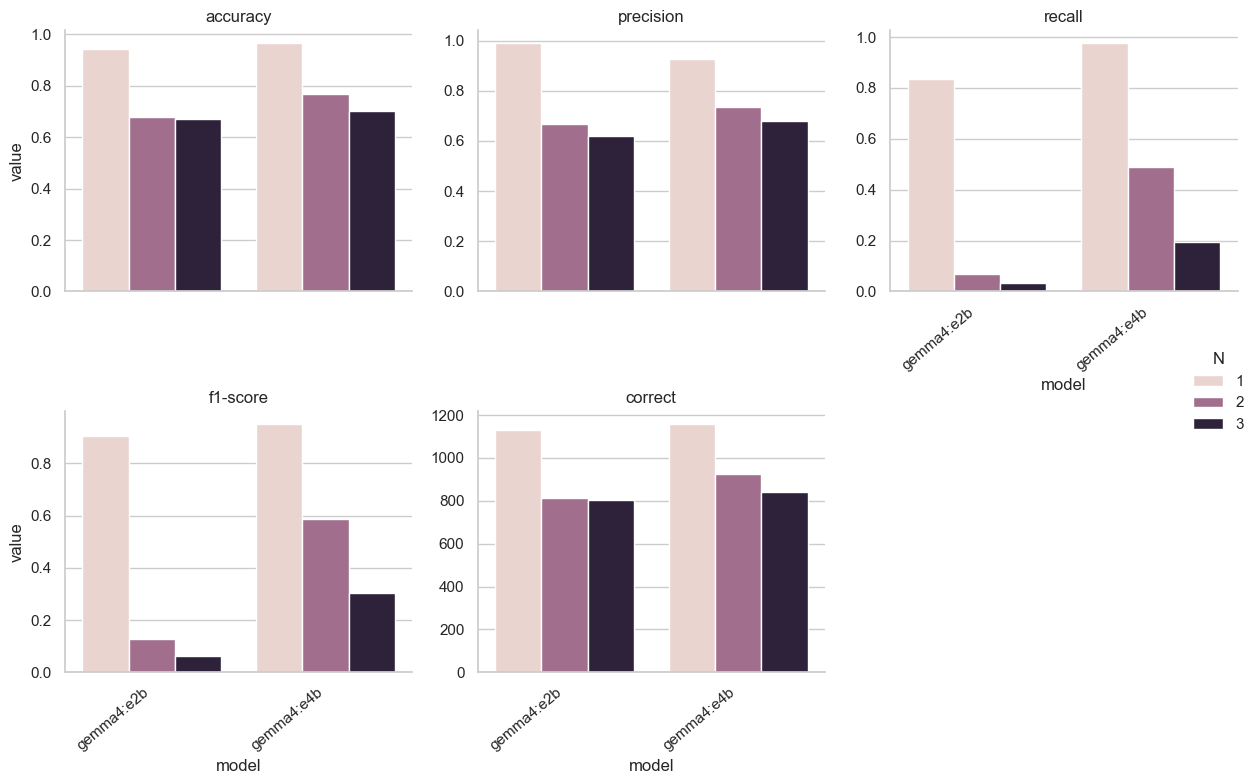

In [16]:
rows = []
for key, summary in all_summary.items():
    n_str, model = key.split("-", 1)
    try:
        n = int(n_str)
    except ValueError:
        n = n_str
    for metric in ["accuracy", "precision", "recall", "f1-score", "correct"]:
        rows.append({
            "N": n,
            "model": model,
            "metric": metric,
            "value": summary.get(metric, None)
        })

df = pd.DataFrame(rows)

sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=df,
    x="model",
    y="value",
    hue="N",
    col="metric",
    kind="bar",
    col_wrap=3,
    height=4,
    sharey=False
)

for ax in g.axes.flatten():
    for label in ax.get_xticklabels():
        label.set_rotation(40)
        label.set_ha("right")
    ax.set_title(ax.get_title().replace("metric = ", ""))

plt.tight_layout()
plt.show()